# Lab Session 3: Part II

In this notebook, you will be building on top of what you learned in the previous lab session.

In these exercises you will be looking at a data set containing about 450 thousand (Swedish) Tweets from  September 2018. What is fun to know is that there were general elections on the 9th of September, and that can be seen in the daily tweet-frequency.

***

<div class="alert alert-block alert-warning">
    
## Task 1

Load the data set "september2018.csv", and show the first few lines. If you look at the raw data, it should have three columns called "DateTime", "UserID", and "Tweet". There is one <strong>extra</strong> thing to do this time: we want to convert the DateTime column to a "real" date time datatype in Pandas. Hint: look up the read_csv command again, and read about the parse_dates option.

Write both commands in the next cell, and then execute it. (Give it some time, it may take up to 10 seconds to read the data.)
</div>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns

In [3]:
#Task 1
#Your code here 
df = pd.read_csv("september2018.csv", sep=";")
print(df.shape)
df.head()


(485491, 3)


,DateTime,UserID,Tweet
0,20180901 00:00:07,guldfiske,@detljuvalivet Sen vet jag ju att Politism ha...
1,20180901 00:00:08,oloffjuss,Det är nu det… After Midnight av J.J. Cale ht...
2,20180901 00:00:11,UppsalaTommy,"@hanifbali @konsensuseliten Är du överraskad,..."
3,20180901 00:00:13,ludde67,Då var man här! Hastigt och lustigt och äntli...
4,20180901 00:00:18,tottetudda,Fundering: vad kommer att hända efter valet 9...


<div class="alert alert-block alert-warning">

## Task 2

Lets get into the analysis!

* 2.1 Who has sent out the most tweets this month? Use the countplot() function of seaborn and show the top 10 most active people!
* 2.2 How many users are their in the data? Make sure labels are readable!
* 2.3 Show the number of tweets per day in a bargraph using seaborn! Make sure labels are readable!
</div>

<Axes: xlabel='count', ylabel='UserID'>

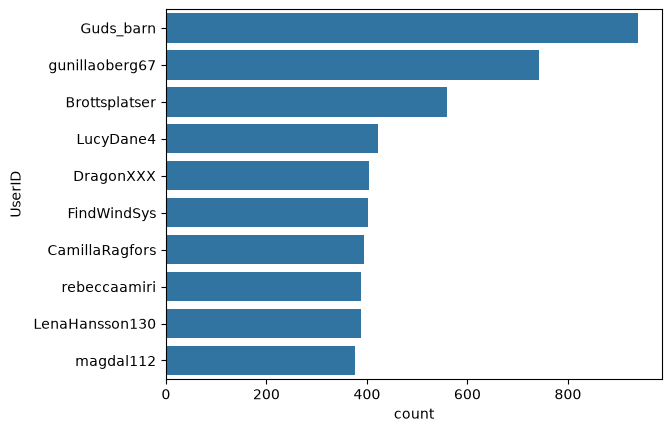

In [4]:
#Task 2.1
plt.figure(1)
#Your code here 
top_10 = df["UserID"].value_counts().head(10).index
sns.countplot(df[df["UserID"].isin(top_10)], y="UserID", order=top_10)


In [5]:
#Task 2.2
#Your code here
unique_users = df["UserID"].nunique()
print("Unique Users in database", unique_users)


Unique Users in database 72442


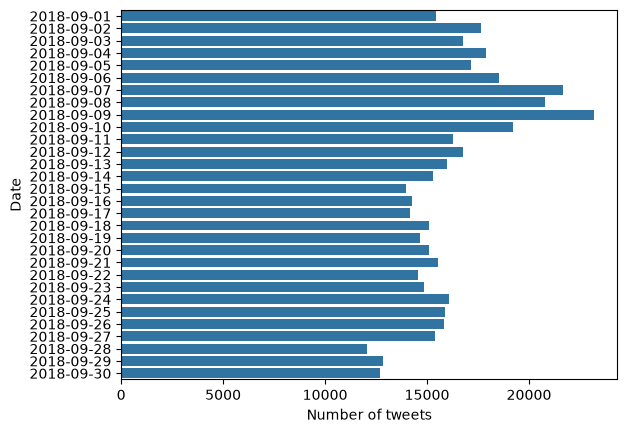

In [6]:
#Task 2.3
plt.figure(2)
#Your code here 
datetime = pd.to_datetime(df["DateTime"], format="%Y%m%d %H:%M:%S")

df["Date"] = datetime.dt.date

counts = df["Date"].value_counts().sort_index()
sns.barplot(x=counts.values, y=counts.index.astype(str))

plt.xlabel("Number of tweets")
plt.show()



<div class="alert alert-block alert-warning">
    
## Task 3

The days around the 9th have seen increased activity! This was infact election day. Lets only look at the day of the election!

* 3.1 Make a new smaller data frame containing only the tweets on the 9th. Call it df1, and print how many tweets there were on that day. Make a bar plot of the number of tweets per hour using seaborn.

* 3.2 Add a new column to df1 called "NumTags" which contains the number of "#" in the "Tweet" column. Hint: look up the Pandas str.count() function. (You will probably get a warning when you execute the code, ignore that for now.)

* 3.3 Who are those hashtag abusers (people that flood their tweets with hashtags)? Print all the names (UserID) of people that have more than 4 hashtags ("NumTags") in their tweets and count the total number of tweets for each of these people (.value_counts()). Only show the top 10 (.head(10)) and save the top 10 in <i>top_tags</i>. Remember: you can use the new column you just created "NumTags" to filter the dataframe. This problem can be done in one line using pandas! To understand the process better, you might want to do this in steps: 1. filter dataframe using "NumTags". 2. Use the UserID column together with value_count() to count the number of tweets per user. 3. use head() to show the top 10 and save the result in top_tags.

* 3.4 Now we have the people (top_tags) that put alot of hashtags in there tweets. From those peoples tweets, extract all tweets with more then 4 hashtags. Remember that top_tags contains the UserIDs of the hashtag abusers. In order to solve this exercise, you can combine several conditions to filter (i.e. df1[condition]) the original dataframe df1 using the column "NumTags" and the UserIDs contained in top_tags. It might look like something like this: df2 = df1[condition1 & condition2] 
    
Now you have all the tweents with alot of hashtags. Let's count how often each hashtag occures in all extracted tweets, i.e. #val2018 : 20, #svepol: 10, etc. We provided you with the dataframe "print_data", your task is to use a barplot to illustrate!


Seems that casino spammers are hard at work!
</div>

(23165, 4)


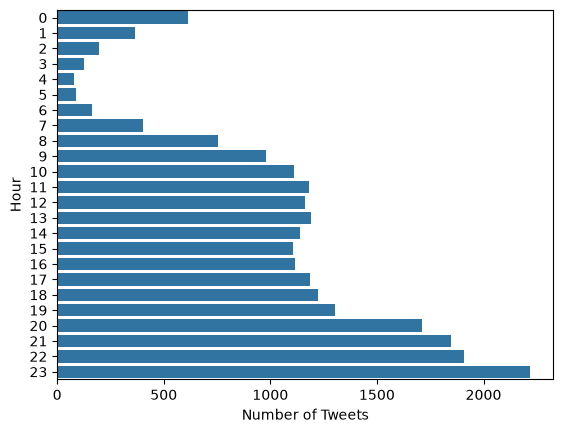

In [7]:
##Task 3.1
#Your code here 
df1 = df.loc[df["Date"] == pd.Timestamp("2018-09-09").date()]
print(df1.shape)
plt.figure(3)
#Your code here, plot!

df1["Hour"] = pd.to_datetime(df1["DateTime"]).dt.hour

counts = df1["Hour"].value_counts().sort_index()

sns.barplot(x=counts.values, y=counts.index.astype(str))
plt.xlabel("Number of Tweets")
plt.ylabel("Hour")
plt.show()


In [8]:
#Task 3.2
#Your code here 
df1["NumTags"] = df1["Tweet"].str.count("#")
df1.head(10)


,DateTime,UserID,Tweet,Date,Hour,NumTags
145876,20180909 00:00:01,RexAdis,@identiteteuropa stockholms stad försökte stä...,2018-09-09,0,0
145877,20180909 00:00:04,froeken_ur,"Klockan är September 09, 2018 at 12:00AM.",2018-09-09,0,0
145878,20180909 00:00:08,ptornroth,@naktergalning @alglader Allt kommer att bli ...,2018-09-09,0,0
145879,20180909 00:00:11,alivebetting,@FACEIT #FACEITMAJOR Challenger stats atm: 25...,2018-09-09,0,1
145880,20180909 00:00:16,MEdnarsson,@strandhall @TV4 @sdriks @Centerpartiet @soci...,2018-09-09,0,1
145881,20180909 00:00:19,herrstapojk666,@konsensuseliten @Fytne Du följer polsk och u...,2018-09-09,0,0
145882,20180909 00:00:33,Danelisa_1,Det blev inte att vi gjorde egen bearnaisesås...,2018-09-09,0,0
145883,20180909 00:00:38,Materye1,@AndersJacobsson Aldrig kan det få vara enkel...,2018-09-09,0,0
145884,20180909 00:00:41,MartinZon2,@EurosportSE Först feminist kortet och objekt...,2018-09-09,0,0
145885,20180909 00:00:46,EC_StockholmRep,"Idag är det inte bara val till riksdagen, lan...",2018-09-09,0,2


In [9]:
#Task 3.3
#Your code here 
top_tags = df1.loc[df1["NumTags"] > 4, "UserID"].value_counts().head(10)
print(top_tags)



UserID
Noterad           5
hilton_dexter     4
HkanLiljeberg     4
Erkilainen87      3
Ylvass            3
BoerjeBrandt      3
Svensk_Seger      3
larsibacken       3
chrwallg          3
RobinJLinghage    2
Name: count, dtype: int64


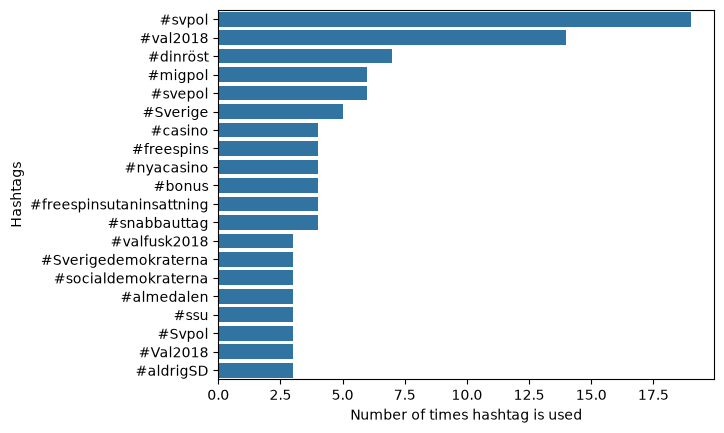

In [10]:
#3.4

df2 = df1[(df1["NumTags"] > 4) & (df1["UserID"].isin(top_tags.index))]

df2["Tags"] = df2.Tweet.apply(lambda x: [w for w in x.split() if "#" in w])
print_data = pd.Series(df2["Tags"].sum()).value_counts().head(20).reset_index(name="Tags")

plt.figure(4)
#Your code here
sns.barplot(data=print_data, x="Tags", y=print_data.columns[0])
plt.xlabel("Number of times hashtag is used")
plt.ylabel("Hashtags")
plt.show()


<div class="alert alert-block alert-warning">
    
## Task 4

Lets look at interactions between users!

* 4.1 Each user has a favorite user to talk to (Identified by the @UserID). Print the number and amount of tweets directed at him/her. i.e.: User1 User2 120. Some steps to acomplish this:
    
    -  4.1.1. Use the .apply() method to extract the Users the tweet is directed at. Use 3.4 (df2["Tags"] = ...) as a guidence on how to extract these users from the tweets using apply. Save the result in the new column "talksto". Remember, tweets directed at specific users include "@UserID" in the message, we therefore can use this to extract the users (like we did in  3.4 to extract hashtags). 
    
    -  4.1.2.For each user, you need to count the occurance of all users (extracted for each tweet before) in the cleaned tweet.
    Tips on how to get going:
        - 4.1.2.1 Use the groupby() method and group by "UserID"
        - 4.1.2.2 On the resulting groupby object call on the cleaned tweets .apply(lambda x: Counter(x.sum()).most_common(1))) and make a dataframe out of the result
        - 4.1.2.3 on the resulting dataframe call .apply(lambda x: x[0][1] if len(x) > 0 else 0) on "talksto" and save the results in "Num"
        - 4.1.2.4 sort dataframe by "Num" decending order and print the top 10.
    

* 4.2 What is the percentage of people that only tweeted once? Remember the "Num" column from before.

* 4.3 What user had the most engangement with different people? Print the number of different people addressed by each user in decending order, print the top 10. Remember 4.1.2.2, use .apply(lambda x: len(set(x.sum()))) instead!

* 4.4 There seems to be an outlier user that tweets to many people! What topic is this user generaly talking about (use google translate)?

* 4.5 Is the user gunillaoberg67 a real person? Look at the tweets and decide!
</div>

In [11]:
#4.1
#most interaction 
#Your code here 
df["talksto"] = df["Tweet"].apply(lambda x: [w for w in x.split() if w.startswith('@')])
df_most = df.groupby("UserID")["talksto"].apply(lambda x: Counter(x.sum()).most_common(1)).to_frame()
df_most["Num"] = df_most["talksto"].apply(lambda x: x[0][1] if len(x) > 0 else 0) 
print(df_most.sort_values("Num", ascending=False).head(10))


                                  talksto  Num
UserID                                        
ShabADFA         [(@FolkessonJenny, 133)]  133
dumskallar         [(@Provokatoren, 114)]  114
Provokatoren         [(@dumskallar, 101)]  101
Erik_Olofsson      [(@Andersson_123, 91)]   91
Andersson_123      [(@Erik_Olofsson, 68)]   68
fininsyn                        [(@, 66)]   66
jespet71               [(@mmsoxford, 65)]   65
RealNobakhtAhad        [(@Expressen, 64)]   64
SaraAnd17564998      [(@Aftonbladet, 61)]   61
OMartinsson          [(@PrivateOlle, 60)]   60


In [13]:
#4.2
#Your code here 
print(len(df_most[df_most["Num"] == 1]) / len(df_most["Num"]) * 100, "%")

48.34488280279396 %


In [17]:
#4.3
#most engangement with different people
#Your code here 
print(df.groupby("UserID")["talksto"].apply(lambda x: len(set(x.sum()))).sort_values(ascending=False).head(10))

UserID
Guds_barn          6393
LucyDane4           406
Jesus_Loves_Me2     372
gunillaoberg67      357
LenaHansson130      341
thereseverdun       331
bella_linne         324
DragonXXX           320
EnCarlssons         319
EnaTyden            304
Name: talksto, dtype: int64


In [ ]:
#4.4
#Your code here
user_tweets = df.loc[df["UserID"].str.strip() == 'Guds_barn', "Tweet"]
print(user_tweets.head(20))

"""Answer here: The user often talks about Jesus Christ warning Sweden"""

1071      @ZarinaZabrisky DEN GUDOMLIGA TREENIGHETEN SA...
10888     @SZakariasson Jesus Kristus Varnar Sverige: h...
10919     @slick_rickard Jesus Kristus Varnar Sverige: ...
10948     @carl70andersson Jesus Kristus Varnar Sverige...
10963     @SuperGuran Jesus Kristus Varnar Sverige: @Ca...
10985     @VonRutger Jesus Kristus Varnar Sverige: @Von...
10988     @SwedishSpaceman Jesus Kristus Varnar Sverige...
10989     @XarxaGnom Jesus Kristus Varnar Sverige: @bul...
11025     @Gustav_Adolf_3 Jesus Kristus Varnar Sverige:...
11084     @KimpaJongIl Jesus Kristus Varnar Sverige: @a...
11096     @Werzion Jesus Kristus Varnar Sverige: @c_her...
11113     @hkeye7 Jesus Kristus Varnar Sverige: @hkeye7...
11166     @MalteRoos Jesus Kristus Varnar Sverige: @1do...
11649     @mimamalm Jesus Kristus Varnar Sverige: @Cars...
11652     @jojjebojjes Jesus Kristus Varnar Sverige: @f...
11656     @AutarkSituation Jesus Kristus Varnar Sverige...
11710     @wille1222 Jesus Kristus Varnar Sverige: @Ber.

'\nAnswer here: \nThe user often talks about Jesus Christ warning Sweden\n'

In [55]:
#4.5
print(df.loc[df["UserID"].str.strip() == 'gunillaoberg67', "Tweet"].head(20))
"""Answer here: The users behaviour is very repetative and would indicate that its a bot"""

116730     @JensAnd09030140 Jösses vilket språk, var har...
118561      @BRGYouTube Kysser du din mamma med den munnen?
118644     @SD2018_ Blir det inte lite trevligare stämni...
120251     @TvartomTom Herrejistanes! Kan vi inte ta det...
120751     @AfS_riks Jag hör vad du säger, men det finns...
121931     @felghen3 Herrejistanes! Kan vi inte ta det l...
122119     @kattaB4 Herrejistanes! Kan vi inte ta det li...
122854     @GustafKaddik Kysser du din mamma med den mun...
123235     @RichardDahlgre1 @alliansswe @sdriks @bjorklu...
123726     @riccardhanzon Debatt är bra, men måste vi ta...
123729     @DitteKarlsson Kysser du din mamma med den mu...
125794     @LightOfStyx @Sharps_Wagner @svt Debatt är br...
126022     @real_bojovic Nu lugnar vi ner oss ett par he...
129242     @PatrikAngelholm Herrejistanes! Nu tar vi det...
129401     @enkritiskfan Kysser du din mamma med den mun...
129919     @Fingemannen Kysser du din mamma med den munnen?
131709     @storspiken @SVTHolmberg @Evl

'Answer here: The users behaviour is very repetative and would indicate that its a bot'